# Scenario-Based Analysis
This notebook analyses the turnaround pathways, highlighting trucks that deviate from the ideal paths across different process stages.

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import os

DATA_DIR = 'data'

# Create figures directory if it doesn't exist
os.makedirs('figures', exist_ok=True)

## 1. Data Loading & Preprocessing

In [2]:
all_pickups = pd.read_csv(os.path.join(DATA_DIR, 'all_pickups.csv'), low_memory=False)
df_success_pickups = pd.read_csv(os.path.join(DATA_DIR, 'success_pickups.csv'), low_memory=False)

gps_processed = pd.read_csv(os.path.join(DATA_DIR, 'gps_processed.csv'), low_memory=False)
pickup_mapping = all_pickups[['Truck ID', 'Pickup Plan ID', 'pickup']].drop_duplicates()
df_gps = gps_processed.merge(pickup_mapping, on=['Truck ID', 'Pickup Plan ID'], how='left')

## 2. Path Stage Classification
Classify GPS path stages.

In [3]:
path_regions = {
    "entry_to_register": {"lat_min": 21.9860, "lat_max": 21.9940, "lon_min": 100.4890, "lon_max": 100.4930},
    "register_to_weigh": {"lat_min": 21.9945, "lat_max": 22.0005, "lon_min": 100.4950, "lon_max": 100.52},
    "weigh_to_yard":     {"lat_min": 22.0080, "lat_max": 22.0150, "lon_min": 100.5250, "lon_max": 100.5450},
    "yard_to_weigh":     {"lat_min": 21.9880, "lat_max": 22.0075, "lon_min": 100.5555, "lon_max": 100.5650},
    "weigh_to_exit":     {"lat_min": 21.98, "lat_max": 21.9850, "lon_min": 100.5655, "lon_max": 100.5700},
}

## 3. Failed Weighing Path Analysis

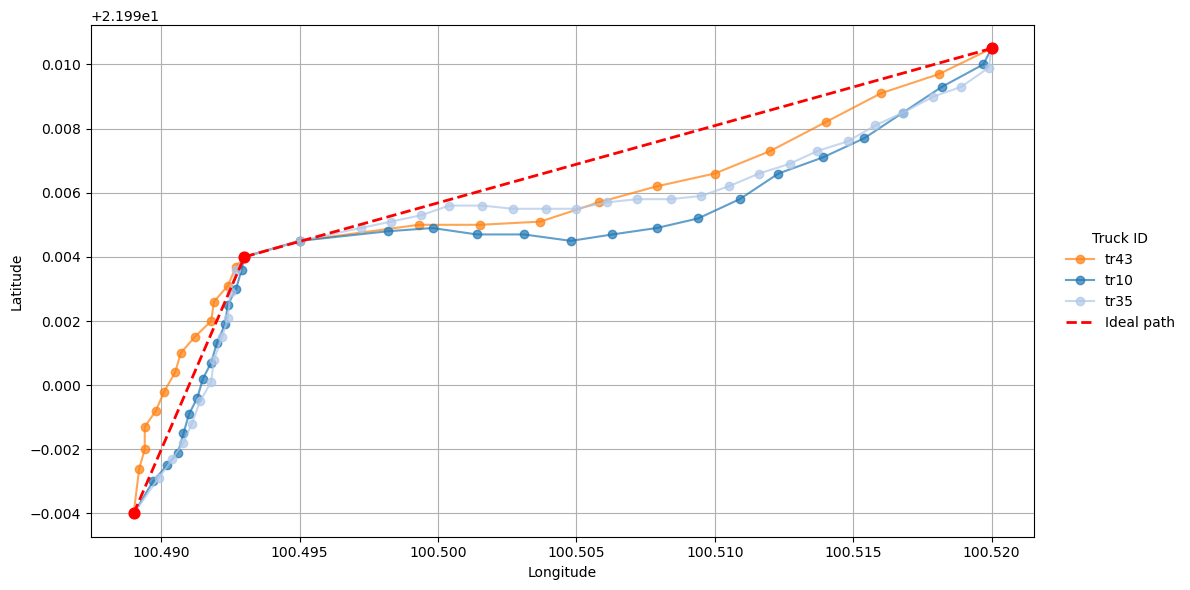

In [4]:
failed_weigh_ids = all_pickups[all_pickups['activity'] == 'Fail to Weigh']['pickup']
failedWeighedGPS = df_gps[df_gps['pickup'].isin(failed_weigh_ids)]

plt.figure(figsize=(12, 6))

truck_ids = failedWeighedGPS['Truck ID'].unique()
palette = sns.color_palette('tab20', n_colors=max(20, len(truck_ids)))
colors = {tid: palette[i % len(palette)] for i, tid in enumerate(truck_ids)}

for rfid, group in failedWeighedGPS.groupby("RFID tag"):
    group = group.sort_values("Timestamp")
    truck_id = group['Truck ID'].iloc[0]  
    lons = group["Longitude"].to_numpy()
    lats = group["Latitude"].to_numpy()
    plt.plot(lons, lats, linestyle='-', marker='o', alpha=0.7,
             color=colors[truck_id], label=str(truck_id))

route = ['entry_to_register', 'register_to_weigh']  
pts = []
for i, st in enumerate(route):
    c = path_regions[st]
    if i == 0:  
        pts.append((c['lon_min'], c['lat_min']))
    pts.append((c['lon_max'], c['lat_max']))

ideal_lons, ideal_lats = zip(*pts)
plt.plot(ideal_lons, ideal_lats, '--', color='red', linewidth=2, label='Ideal path')
plt.scatter(ideal_lons, ideal_lats, c='red', s=60, zorder=5)

plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.legend(loc='center left', bbox_to_anchor=(1.02, 0.5), frameon=False, title="Truck ID")
plt.grid(True)
plt.tight_layout()
plt.savefig('figures/failedWeight_path.png', dpi=300)
plt.show()

## 4. Path Deviation Analysis (Successful Pickups)
Helper function and execution for plotting trucks that exceed TTL thresholds.

In [5]:
df_success_pickups_ids = df_success_pickups['pickup'].unique()
df_gps_success = df_gps[df_gps['pickup'].isin(df_success_pickups_ids)]

def plot_path_deviation(df_gps_data, pickup_ids_to_plot, path_stage, routes, ideal_text, text_x_offset, text_y_offset_idx, filename):
    df_filtered = df_gps_data[df_gps_data['pickup'].isin(pickup_ids_to_plot)]
    df = df_filtered[df_filtered['Path_Stage'] == path_stage].copy()
    
    plt.figure(figsize=(12, 6))

    combo_ids = df[['Truck ID', 'pickup']].dropna().drop_duplicates()
    palette = sns.color_palette('tab20', n_colors=max(20, len(combo_ids)))
    color_map = {tuple(row): palette[i % len(palette)] for i, row in enumerate(combo_ids.to_numpy())}

    for (tid, pid), g in df.groupby(['Truck ID', 'pickup']):
        g = g.sort_values('Timestamp')
        lons = g['Longitude'].to_numpy()
        lats = g['Latitude'].to_numpy()

        plt.plot(
            lons, lats,
            linestyle='-',
            marker='o', markersize=5,
            alpha=0.8,
            color=color_map.get((tid, pid), 'gray'),
            label=f"{tid} (Pickup {int(pid)})"
        )

    pts = []
    for i, st in enumerate(routes):
        c = path_regions[st]
        if i == 0:
            pts.append((c['lon_min'], c['lat_min']))
        pts.append((c['lon_max'], c['lat_max']))

    ideal_lons, ideal_lats = zip(*pts)
    plt.plot(ideal_lons, ideal_lats, '--', color='red', linewidth=2)
    plt.scatter(ideal_lons, ideal_lats, c='red', s=60, zorder=5)

    mid = len(ideal_lons) // 2
    plt.text(
        ideal_lons[mid] + text_x_offset, ideal_lats[mid] if text_y_offset_idx is None else ideal_lats[text_y_offset_idx],
        ideal_text,
        color='red', fontsize=14, va='center', ha='left',
        backgroundcolor='white'
    )

    plt.xlabel("Longitude", fontsize=15)
    plt.ylabel("Latitude", fontsize=15)
    plt.tick_params(axis='x', labelsize=13)
    plt.tick_params(axis='y', labelsize=13)
    plt.legend(loc='center left', bbox_to_anchor=(1.02, 0.5), frameon=False, title="Truck ID & Pickup", fontsize=14)
    plt.grid(True)
    plt.tight_layout()
    plt.savefig(f'figures/{filename}', dpi=300)
    plt.show()

# Get a deduplicated DataFrame with max TTL counts per pickup for filtering
df_success_pickups_filtered = df_success_pickups[['pickup','Truck ID','Enter_to_Register_TTL_count','Register_to_WeighEmpty_TTL_count','WeighEmpty_to_ArriveSilo_TTL_count','Stack_Loaded_TTL_count','WeighLoaded_to_Exit_TTL_count']].drop_duplicates()

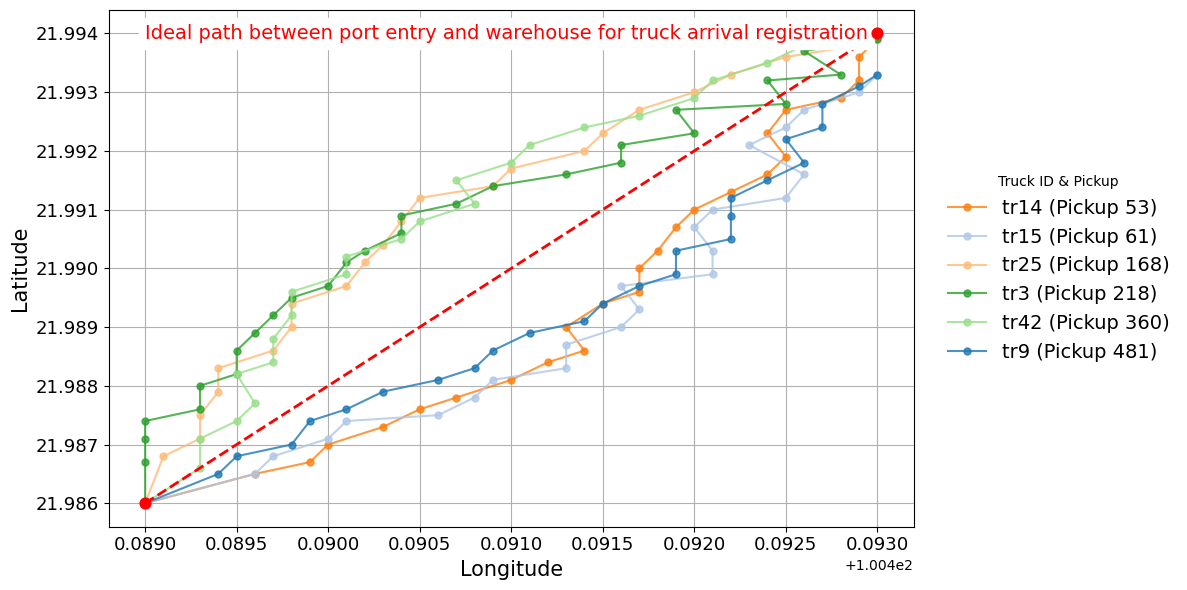

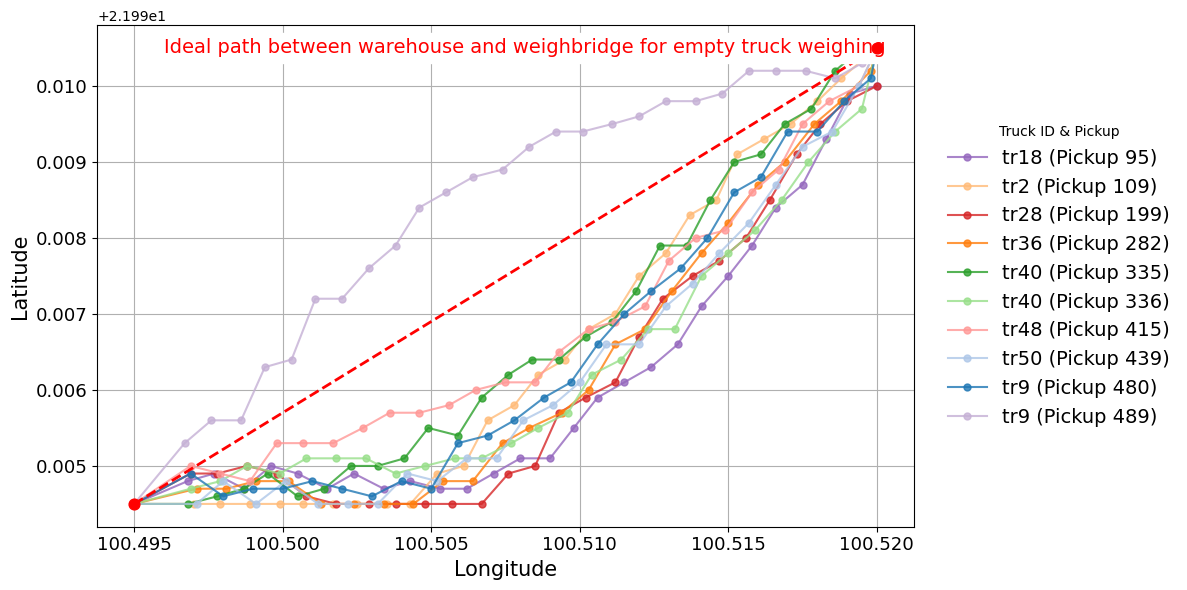

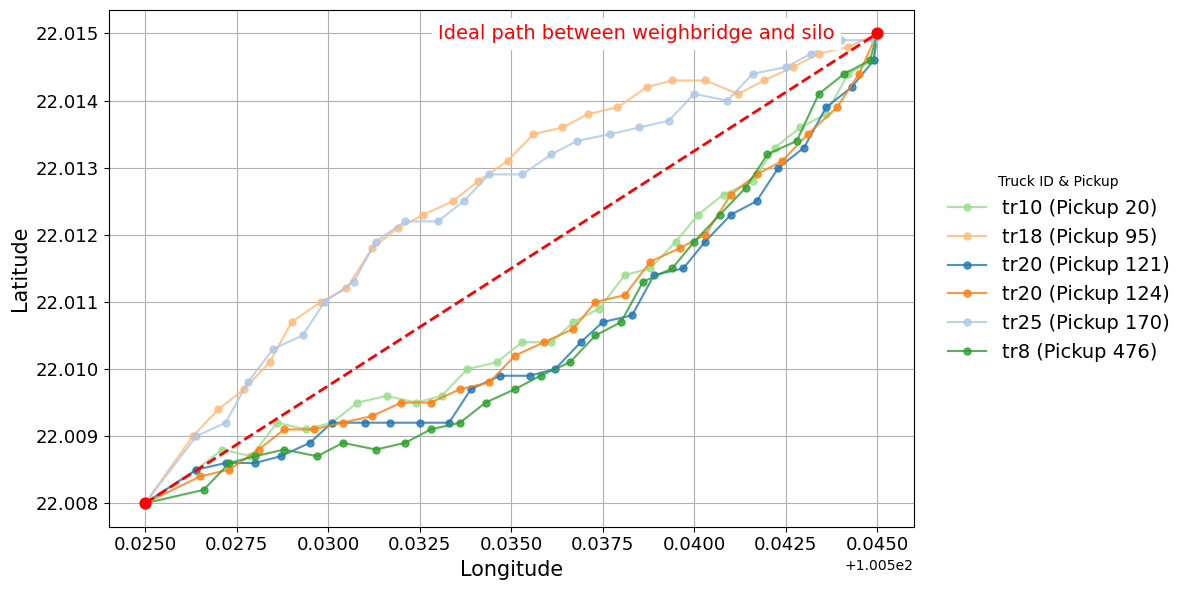

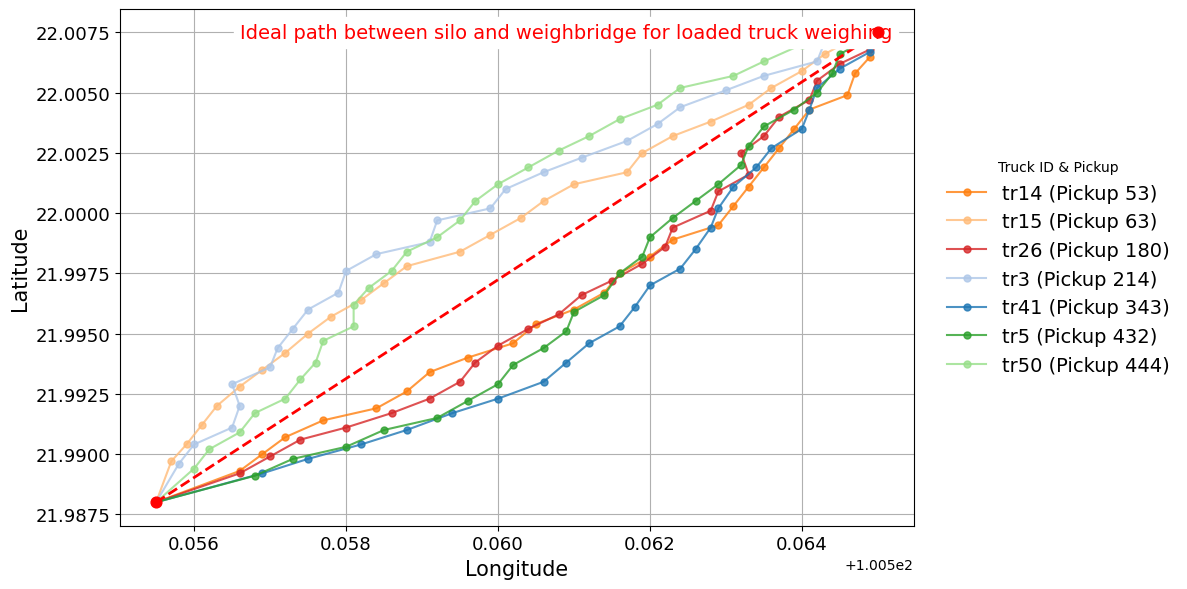

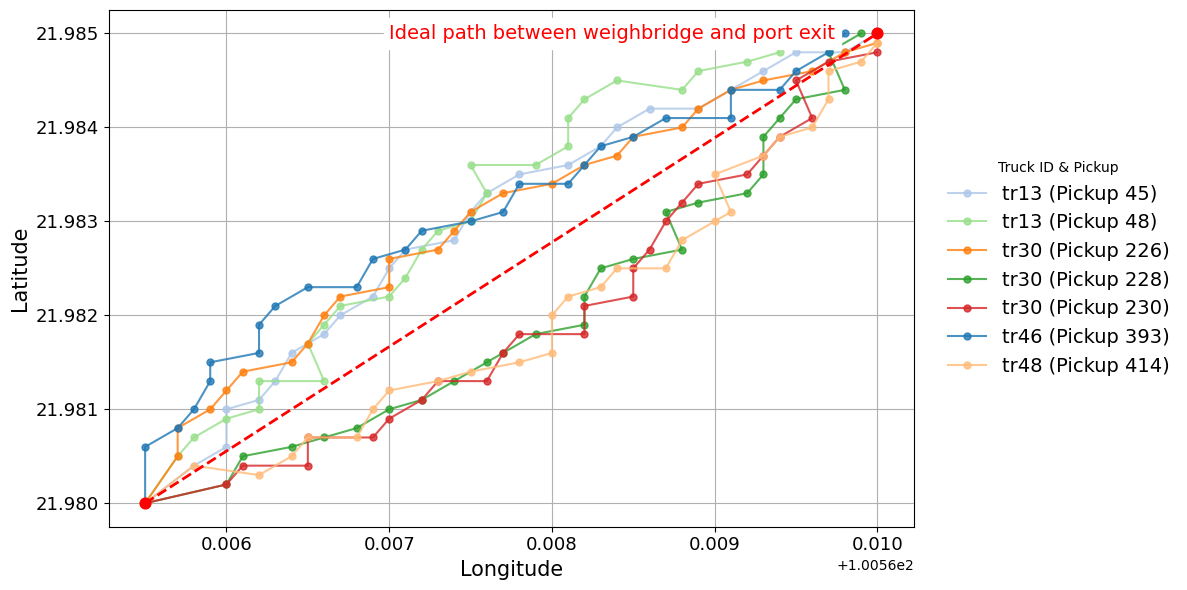

In [6]:
# Figure: Entry to Warehouse
p_ids = df_success_pickups_filtered[df_success_pickups_filtered['Enter_to_Register_TTL_count'] > 20]['pickup']
plot_path_deviation(df_gps_success, p_ids, 'entry_to_register', ['entry_to_register'], 
                    'Ideal path between port entry and warehouse for truck arrival registration', 
                    -0.004, None, 'bad_pickups_entry_warehouse.png')

# Figure: Warehouse to Empty Weighing
p_ids = df_success_pickups_filtered[df_success_pickups_filtered['Register_to_WeighEmpty_TTL_count'] > 23]['pickup']
plot_path_deviation(df_gps_success, p_ids, 'register_to_weigh', ['register_to_weigh'], 
                    'Ideal path between warehouse and weighbridge for empty truck weighing', 
                    -0.024, None, 'bad_pickups_warehouse_emptyweighing.png')

# Figure: Empty Weighing to Silo
p_ids = df_success_pickups_filtered[df_success_pickups_filtered['WeighEmpty_to_ArriveSilo_TTL_count'] > 23]['pickup']
plot_path_deviation(df_gps_success, p_ids, 'weigh_to_yard', ['weigh_to_yard'], 
                    'Ideal path between weighbridge and silo', 
                    -0.012, None, 'bad_pickups_emptyweighing_silo.png')

# Figure: Silo to Loaded Weighing
p_ids = df_success_pickups_filtered[df_success_pickups_filtered['Stack_Loaded_TTL_count'] > 23]['pickup']
plot_path_deviation(df_gps_success, p_ids, 'yard_to_weigh', ['yard_to_weigh'], 
                    'Ideal path between silo and weighbridge for loaded truck weighing', 
                    -0.0084, None, 'bad_pickups_silo_loadedweighing.png')

# Figure: Loaded Weighing to Exit
p_ids = df_success_pickups_filtered[df_success_pickups_filtered['WeighLoaded_to_Exit_TTL_count'] > 20]['pickup']
plot_path_deviation(df_gps_success, p_ids, 'weigh_to_exit', ['weigh_to_exit'], 
                    'Ideal path between weighbridge and port exit', 
                    -0.003, None, 'bad_pickups_loadedweighing_exit.png')

## 5. Unauthorised Location Threshold Analysis

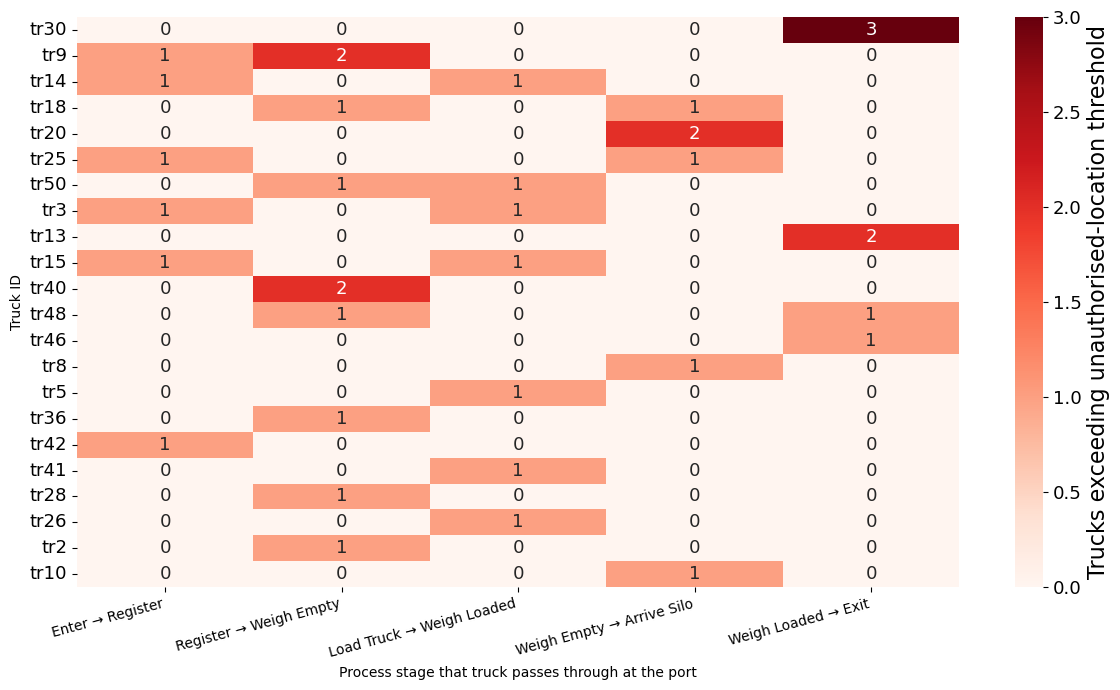

In [7]:
THR = {
    'Enter_to_Register_TTL_count':        20,
    'Register_to_WeighEmpty_TTL_count':   23,
    'WeighEmpty_to_ArriveSilo_TTL_count': 23,
    'Stack_Loaded_TTL_count':             23,
    'WeighLoaded_to_Exit_TTL_count':      20,
}
PATH_COLS = list(THR.keys())

df_agg = df_success_pickups_filtered.copy()
df_agg[PATH_COLS] = df_agg[PATH_COLS].apply(pd.to_numeric, errors='coerce').fillna(0)

mask_df = pd.DataFrame({c: df_agg[c].gt(THR[c]) for c in PATH_COLS}, index=df_agg.index)
df_agg['is_unexpected'] = mask_df.any(axis=1)
df_agg['exceeded_paths'] = mask_df.apply(lambda r: [c for c, v in r.items() if v], axis=1)

unexpected = df_agg[df_agg['is_unexpected']]
df_exploded = unexpected.explode('exceeded_paths')

XTICK_ROTATE_DEG = 15      

pretty_path = {
    'Enter_to_Register_TTL_count':       'Enter → Register',
    'Register_to_WeighEmpty_TTL_count':  'Register → Weigh Empty',
    'Stack_Loaded_TTL_count':            'Load Truck → Weigh Loaded',
    'WeighEmpty_to_ArriveSilo_TTL_count':'Weigh Empty → Arrive Silo',
    'WeighLoaded_to_Exit_TTL_count':     'Weigh Loaded → Exit',
}
counts_df = df_exploded.groupby(['Truck ID', 'exceeded_paths']).size().reset_index(name='count')
pivot_df = counts_df.pivot(index='Truck ID', columns='exceeded_paths', values='count').fillna(0)
pivot_df = pivot_df.loc[pivot_df.sum(axis=1).sort_values(ascending=False).index]
pivot_df = pivot_df.rename(columns=pretty_path)

plt.figure(figsize=(12, 7))
ax = sns.heatmap(
    pivot_df,
    annot=True,         
    fmt=".0f",           
    cmap="Reds",      
    linecolor="white",   
    cbar_kws={'label': 'Count of trucks exceeding unauthorised-location threshold'},
    annot_kws={'size': 13} 
)

plt.xlabel('Process stage that truck passes through at the port')
plt.ylabel('Truck ID')
plt.tick_params(axis='y', labelsize=13)
plt.xticks(rotation=XTICK_ROTATE_DEG, ha='right')

cbar = ax.collections[0].colorbar       
cbar.set_label('Trucks exceeding unauthorised-location threshold', size=16)
cbar.ax.tick_params(labelsize=13)

plt.tight_layout()
plt.savefig('figures/process_stage_unauthorised_trucks.png', dpi=300)
plt.show()
